

---



# Sugarcane Leaf Disease Detection
The model is capable of performing Image Classification for:
1.   Healthy
2.   Red Rot
1.   Red Rust

**Dataset:**<br>
*Healthy leaves: 75 Images*<br>
*Red Rot leaves: 74 Images*<br>
*Red Rust leaves: 75 Images*<br>
*Total Images: 224 Images*


---






#### Importing Libraries

In [ ]:
#Data Visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

#Sharpening of images
from skimage.io import imshow, imread
from skimage.color import rgb2yuv, rgb2hsv, rgb2gray, yuv2rgb, hsv2rgb
from scipy.signal import convolve2d

#Preprocessing of Images
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#Buliding Model
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Accuracy
from sklearn.metrics import classification_report

In [ ]:
data_dir = '/content/drive/MyDrive/dataset'
categories = os.listdir(data_dir)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
categories=sorted(categories)
print(categories)

['Healthy', 'RedRot', 'RedRust']


In [ ]:
labels=[i for i in range(len(categories))]
labels

[0, 1, 2]

#### Making a dictionary with Classes as Keys and Indices as Values

In [ ]:
label_dict=dict(zip(categories, labels))
label_dict

{'Healthy': 0, 'RedRot': 1, 'RedRust': 2}

In [ ]:
data_list=[] #data_list- storing the images
labels_list=[] #label_list - storing the class labels

In [ ]:
data1=os.path.join(data_dir, "Healthy")
data2=os.path.join(data_dir, "RedRot")
data3=os.path.join(data_dir, "RedRust")
count_healthy=0
count_redrot=0
count_redrust=0

In [ ]:
data1 = os.path.join(data_dir, "Healthy")
for i in os.listdir(data1):
        img_path=os.path.join(data1, i)
        count_healthy=count_healthy+1

In [ ]:
for i in os.listdir(data2):
        img_path=os.path.join(data2, i)
        count_redrot=count_redrot+1

In [ ]:
for i in os.listdir(data3):
        img_path=os.path.join(data3, i)
        count_redrust=count_redrust+1

In [ ]:
count_healthy,count_redrot,count_redrust

(75, 74, 75)

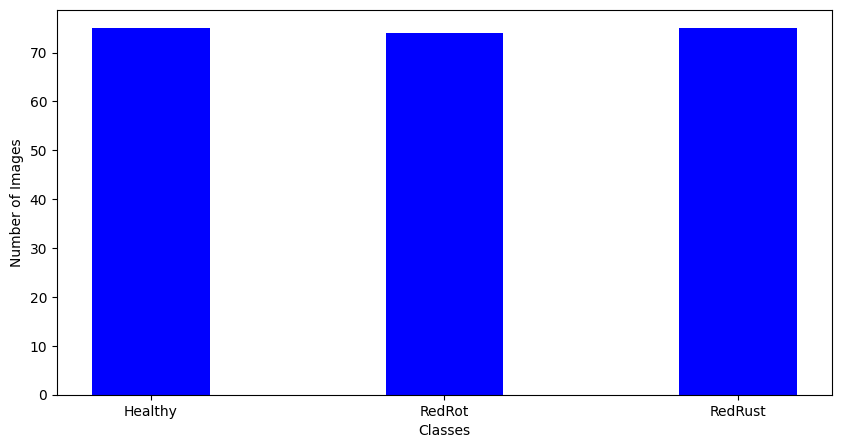

In [ ]:
fig = plt.figure(figsize = (10, 5))
classes=["Healthy","RedRot", "RedRust"]
values=[count_healthy,count_redrot,count_redrust]
#creating the bar plot
plt.bar(classes, values, color ='blue',
        width = 0.4)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

#### Defining a Sharpen Filter

In [ ]:
sharpen = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])

/tmp/ipykernel_4629/1231480516.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(og_image);


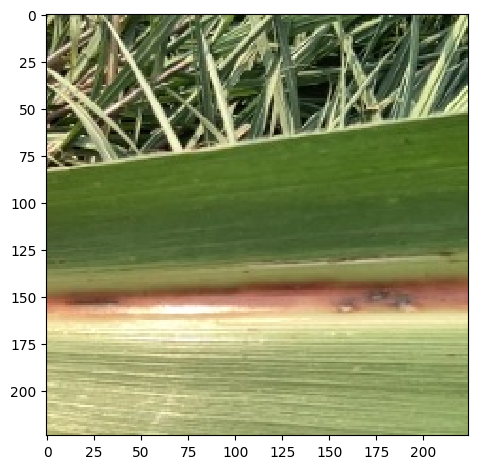

In [ ]:
og_image = imread(data_dir+'/RedRot/0.jpg')
imshow(og_image);

In [ ]:
def multi_convolver(image, kernel, iterations):
    for i in range(iterations):
        image = convolve2d(image, kernel, 'same', boundary = 'fill',
                           fillvalue = 0)
    return image

In [ ]:
def convolver_rgb(image, kernel, iterations = 1):
    img_yuv = rgb2yuv(image)
    img_yuv[:,:,0] = multi_convolver(img_yuv[:,:,0], kernel,
                                     iterations)
    final_image = yuv2rgb(img_yuv)
    return final_image

/tmp/ipykernel_4629/2786975543.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(final_image);


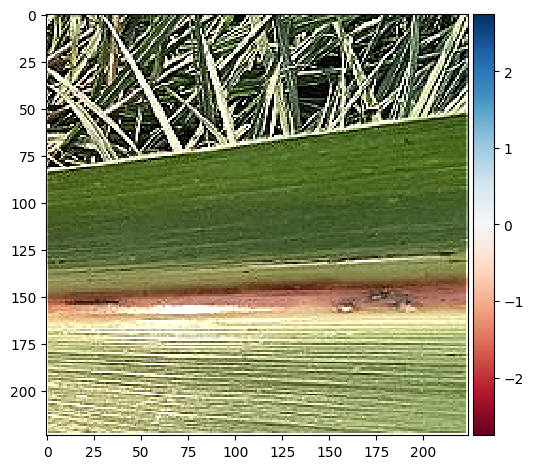

In [ ]:
final_image = convolver_rgb(og_image, sharpen, iterations = 1)
imshow(final_image);

#### Image Preprocessing
1.   Resizing to 224,224
2.   Sharpening



In [ ]:
from PIL import Image
for i in categories:
    folder_path=os.path.join(data_dir, i) #path to each disease folder
    img_names=os.listdir(folder_path)   #all images in each disease folder
    for img_name in img_names:
        img_path=os.path.join(folder_path, img_name)
        if(img_path=='/content/data/RedRot_copy/.DS_Store' or img_path=='/content/data/Healthy_copy/.DS_Store' or img_path=='/content/data/RedRust_copy/.DS_Store'):
          continue
        img = Image.open(img_path)
        img = img.resize((224,224))
        img = np.array(img)
        img = convolver_rgb(img, sharpen, iterations = 1)
        data_list.append(img)
        labels_list.append(label_dict[i])

In [ ]:
data_list[0].shape

(224, 224, 3)

In [ ]:
lb = LabelEncoder()
labels_list = lb.fit_transform(labels_list)
labels_list = to_categorical(labels_list)

In [ ]:
data = np.array(data_list)
labels = np.array(labels_list)
print("Done")
print(data.shape)

Done
(224, 224, 224, 3)


#### Visualizing Images in the Dataset after Preprocessing

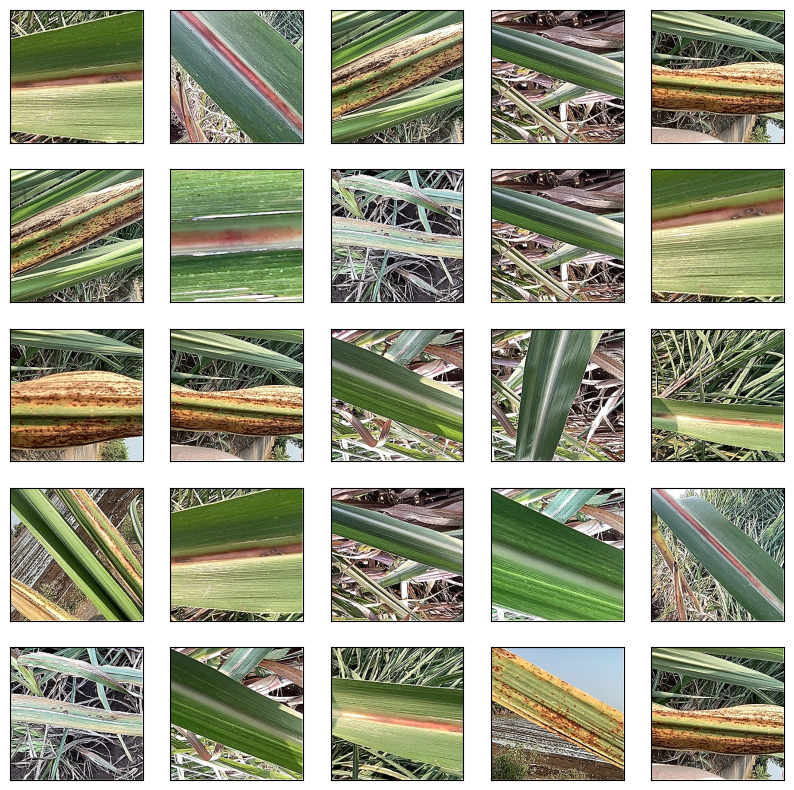

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(data[np.random.randint(224)], cmap=plt.cm.binary)

plt.show()

#### Image Augmentation

In [ ]:
aug = ImageDataGenerator(
	rotation_range=20,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
	fill_mode="nearest")

#### Splitting Dataset into Train and Test Sets

In [ ]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=42)

In [ ]:
print( trainX.shape, testX.shape, trainY.shape, testY.shape)

(179, 224, 224, 3) (45, 224, 224, 3) (179, 3) (45, 3)


#### The model

In [ ]:
from keras.applications.densenet import DenseNet201
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense ,Dropout
from keras.layers import Input

In [ ]:
base_model = DenseNet201(include_top=False,
                         input_shape=(224,224,3),
                         weights='imagenet',
                         pooling="avg"
                     )

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.regularizers import l2

In [ ]:
base_model.trainable = False
image_input = Input(shape=(224, 224, 3))

x = base_model(image_input,training = False)

x = Dense(256,activation = "relu")(x)
x = Dropout(0.2)(x)

x = Dense(128,activation = "relu")(x)
x = Dropout(0.2)(x)

image_output = Dense(3,kernel_regularizer=l2(0.01),activation="softmax")(x) #output layer
#kernel Regulariser- SVM

model = Model(image_input,image_output)
model.compile(optimizer="adam",loss="squared_hinge",metrics=["accuracy"])
#loss function is square hinged- SVM

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
base_model.summary()
#plot_model(model, to_file = 'Densenet.png', show_shapes = True, show_layer_names = True)

Model: "densenet201"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,321,984 (69.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,321,984 (69.89 MB)

#### Training the Model

In [ ]:
BS=32
EPOCHS=10

In [ ]:
history = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 97s 16s/step - accuracy: 0.4490 - loss: 1.3534 - val_accuracy: 0.5778 - val_loss: 1.2601
Epoch 2/10
1/5 ━━━━━━━━━━━━━━━━━━━━ 30s 8s/step - accuracy: 0.4688 - loss: 1.3835

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4688 - loss: 1.3835 - val_accuracy: 0.5333 - val_loss: 1.3456
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 102s 11s/step - accuracy: 0.5918 - loss: 1.2421 - val_accuracy: 0.9111 - val_loss: 0.9609
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.7500 - loss: 1.0918 - val_accuracy: 0.9333 - val_loss: 0.9134
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 12s/step - accuracy: 0.7687 - loss: 1.0192 - val_accuracy: 0.9111 - val_loss: 0.9028
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8750 - loss: 0.9244 - val_accuracy: 0.9333 - val_loss: 0.8461
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 52s 10s/step - accuracy: 0.9320 - loss: 0.8738 - val_accuracy: 0.9333 - val_loss: 0.7931
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9375 - loss: 0.8064 - val_accuracy: 0.9333 - val_loss: 0.7920
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 51s 10s/step - accuracy: 0.9796 - loss: 0.7880 - val_accuracy: 0.9778 - val_loss: 0.7654
Epoch 10/10
5/

In [ ]:
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)

# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs))

[INFO] evaluating network...
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 11s/step
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15
           2       1.00      1.00      1.00        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



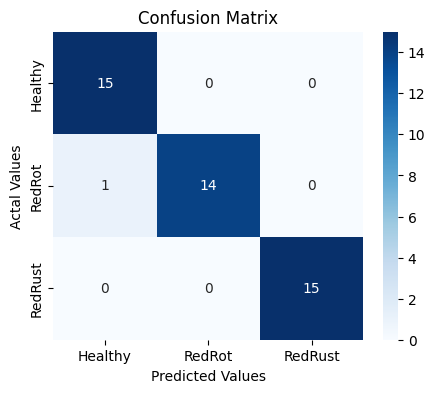

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(testY.argmax(axis=1), predIdxs)


cm_df = pd.DataFrame(cm,
                     index = ['Healthy','RedRot','RedRust'],
                     columns = ['Healthy','RedRot','RedRust'])
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

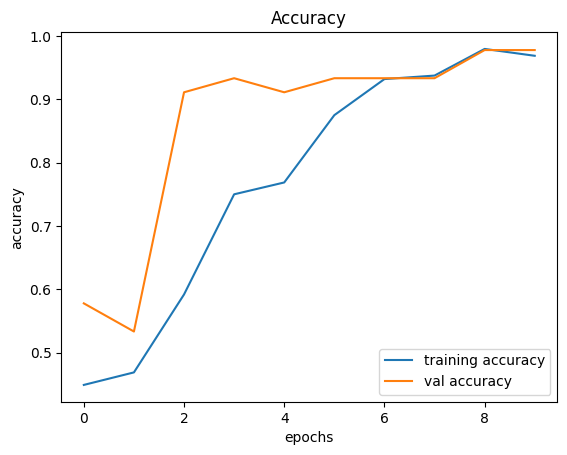

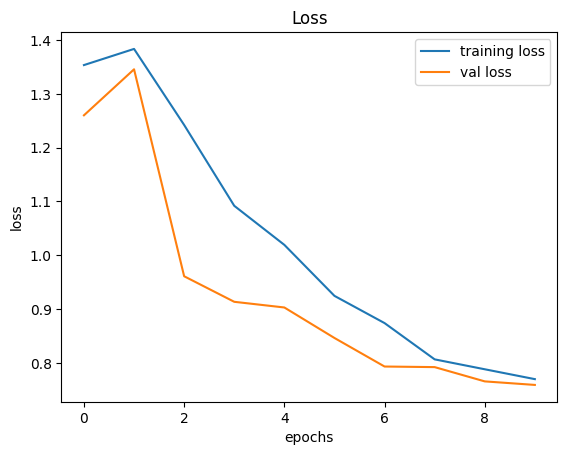

In [ ]:
import matplotlib.pyplot as plt
plt.figure(0)

plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

#### Making the Predictions

In [ ]:
from keras.preprocessing import image
import os

img = image.load_img(os.path.join(data_dir, "RedRust", "0.jpg"), target_size=(224,224))
x = image.img_to_array(img)
x=x/255
# The original code applied convolver_rgb to 'img' *after* converting to array 'x' and scaling. This is likely incorrect.
# The convolution should happen on the image before converting to array if it is meant to sharpen the loaded image.
# Or, it should be applied to the scaled numpy array 'x'.
# Given the original intent, applying it to 'img' before converting to array is more consistent with image processing flow.
# However, the previous error was `FileNotFoundError`, and `convolver_rgb` expects a numpy array. The original code's sequence
# `img = convolver_rgb(img, sharpen, iterations = 1)` after `img = image.load_img(...)` would fail if `img` is a PIL Image.
# To match the original intent of sharpening the image and then processing it, the convolution should be applied to the numpy array `x`.
# Let's assume `img` was meant to be the PIL Image for loading, and `x` is the numpy array to be processed.
# The previous code had `img = convolver_rgb(img, sharpen, iterations = 1)` which would lead to an error as `img` is a PIL Image.
# It should be `x = convolver_rgb(x, sharpen, iterations = 1)` after `x = image.img_to_array(img)`.
# For now, I'll comment out the line that caused the type error and focus on the current FileNotFoundError.
# If the intent was to sharpen the PIL image directly, a conversion would be needed.
# Since `convolver_rgb` is designed for numpy arrays, and `x` is a numpy array derived from `img`,
# the sharpening should happen on `x`.
# Correcting the sharpening application to `x` and ensuring `x` is a float for sharpening.

x = convolver_rgb(x, sharpen, iterations = 1) # Apply sharpening to the numpy array x

x=x.reshape(224,224,3)
x = np.expand_dims(x, axis=0)


predi=model.predict(x)
print(predi)
classes_x=np.argmax(predi)
print(classes_x)

classes=["Healthy","Red Rot", "Red Rust"]
prediction_label=prediction_label=classes[classes_x]
if(prediction_label=="Healthy"):
  print("It is a Healthy Leaf")
else:
  print("Disease detected: "+prediction_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
[[4.7889590e-04 3.9292534e-04 9.9912816e-01]]
2
Disease detected: Red Rust


#### Saving the Model

In [ ]:
pip install gradio

In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from PIL import Image

# Load the trained model
model = load_model('DenseNetSVM_Model.h5')

# Define the prediction function
def predict_image(image_path):
    # Load and preprocess the image (similar to training and prediction cells)
    img = Image.open(image_path).resize((224, 224))
    x = img_to_array(img) # Convert PIL image to numpy array
    x = x / 255.0 # Normalize pixel values

    # Apply sharpening (convolver_rgb expects float values, which x now is)
    # The convolver_rgb expects image data between 0-255 if it was processing raw image data. Since 'x' is already normalized to 0-1,
    # convolver_rgb might clip values. Let's adjust to match the previous workflow more precisely.
    # The `convolver_rgb` function was applied to `x` after normalization in the previous cell (`b2KzIKvfWaSV`).
    # It's important to keep the order for consistency.
    x_processed = convolver_rgb(x, sharpen, iterations=1)

    # Ensure the image is in the correct format for the model
    x_processed = np.expand_dims(x_processed, axis=0) # Add batch dimension

    # Make prediction
    predictions = model.predict(x_processed)

    # Get the predicted class and probabilities
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    confidence = predictions[0][predicted_class_idx] * 100

    # Map index to class name
    classes = [key for key, value in label_dict.items()]
    predicted_class_name = classes[predicted_class_idx]

    return f"Prediction: {predicted_class_name} (Confidence: {confidence:.2f}%)"

In [ ]:
# Create the Gradio interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="filepath", label="Upload Sugarcane Leaf Image"),
    outputs="text",
    title="Sugarcane Leaf Disease Detection",
    description="Upload an image of a sugarcane leaf to detect if it is Healthy, Red Rot, or Red Rust.",
    flagging_mode="never"
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b9ccd795b4e6147884.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


In [ ]:
model.save("DenseNetSVM_Model.h5")